# 02 — Hand Keypoint Autoencoder (with image overlay)

We train a **linear autoencoder** on **63-dim hand keypoints** (21 landmarks × 3). Optionally set **`USE_VQ = True`** in the training cell for a **VQ-VAE** (EMA-reset codebook from `vq_layer.py`, `nb_code=512`, `commit_weight=0.02`).
For visualization, we overlay original vs reconstructed keypoints on the corresponding hand images (no image-based training).

**Data**: One **CSV** (path, label, 63 landmark columns) plus **raw images** in a folder. Paths in the CSV are relative to the image folder. The landmarks were obtained with **MediaPipe** (hand landmarker); only the CSV and raw images are shared — extraction code is not included. Set **LETTERS** below to choose which letters (classes) to use for training and inference.

#### Set up Drive and dependencies when running on Google Colab
Othersie, skip the following two cells.

In [ ]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# change the working directory
repo_url = "https://github.com/pjyazdian/VQVAE-INN-Workshop.git"
repo_name = "VQVAE-INN-Workshop"
repo_path = f"/content/drive/MyDrive/{repo_name}"
%cd {repo_path}

## Imports

In [1]:
import torch
import numpy as np
from pathlib import Path
from utils import (
    get_device,
    get_hand_csv_loaders,
    LinearAE,
    AETrainer,
    scatter_latent,
    plot_hand_keypoints_on_image,
)

/localhome/pjomeyaz/anaconda3/envs/motionagent/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data
Set **LETTERS** to the list of letters (classes) to use. Leave as `None` to use all letters in the CSV. Then set the CSV path and the folder containing raw images (paths in CSV are relative to this folder).

In [2]:
# Which letters to use for training and inference (None = use all in CSV)
LETTERS = ["A", "B", "C", "D", "F", "G", "H", "L", "P", "Q", "W", "Y"]
CSV_PATH = "./data/ASL_Dataset/hand_landmarks_workshop.csv"
IMAGE_ROOT = "./data/ASL_Dataset/ASL_Data"

train_loader_img, val_loader_img, train_loader_kp, val_loader_kp = get_hand_csv_loaders(
    CSV_PATH, IMAGE_ROOT, letters=LETTERS, batch_size=16, val_ratio=0.2, img_size=(128, 128)
)
print("Hand data: train batches (img)", len(train_loader_img), "(kp)", len(train_loader_kp),
      "| val batches (img)", len(val_loader_img), "(kp)", len(val_loader_kp))


Hand data: train batches (img) 606 (kp) 606 | val batches (img) 152 (kp) 152


#### Visualize the data
Visualize the sample data

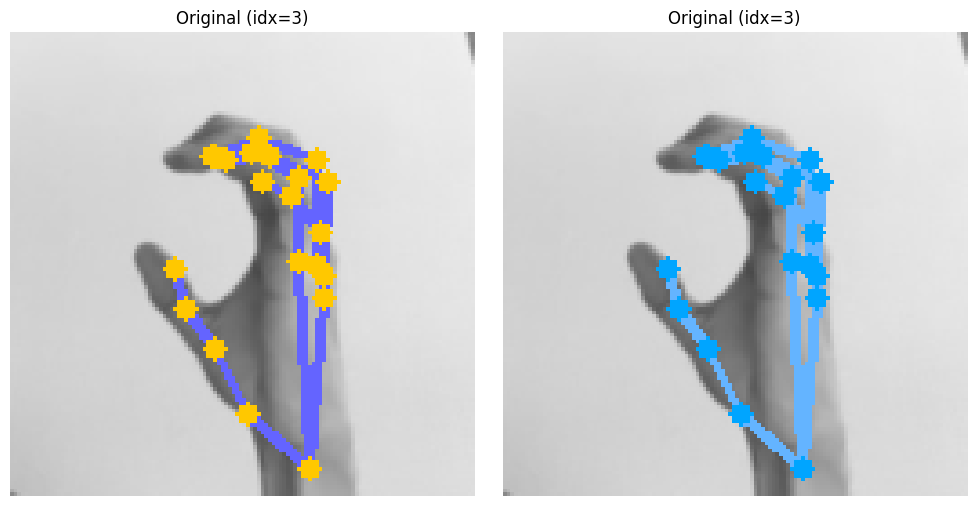

In [18]:
#here write a code, that we could pick a sample index and visualize it with overlaping keypoint on imag.
# Choose a sample index to visualize
sample_idx = 3  # Change this index to pick a different sample

# Fetch one batch from both image and keypoint dataloaders (order matches!)
data_img, _ = next(iter(train_loader_img))
data_kp, _ = next(iter(train_loader_kp))

# Select the sample
img_sample = data_img[sample_idx]
kp_sample = data_kp[sample_idx]

# Since plot_hand_keypoints_on_image expects both original and reconstructed keypoints,
# just duplicate the keypoints for visualization (original=left, recon=right).
plot_hand_keypoints_on_image(
    img_sample,
    kp_sample.cpu().numpy(),
    kp_sample.cpu().numpy(),  # duplicate for "reconstructed" just for visualization
    title_left=f"Original (idx={sample_idx})",
    title_right=f"Original (idx={sample_idx})",
)


---
## Training Hand keypoint Autoencoder (63-dim)

In [19]:
device = get_device()
# Set USE_VQ=True for VQ-VAE
model_kp = LinearAE(
    latent_dim=16,
    input_dim=63,
    hidden_dim=1024)
trainer_kp = AETrainer(model_kp, train_loader_kp, val_loader_kp, device=device)
trainer_kp.run(n_epochs=10)

====> Epoch: 1 Train loss: 0.0020
====> Epoch: 1 Val loss: 0.0001


====> Epoch: 2 Train loss: 0.0001
====> Epoch: 2 Val loss: 0.0001


====> Epoch: 3 Train loss: 0.0001
====> Epoch: 3 Val loss: 0.0001


====> Epoch: 4 Train loss: 0.0001
====> Epoch: 4 Val loss: 0.0001


====> Epoch: 5 Train loss: 0.0001
====> Epoch: 5 Val loss: 0.0001


====> Epoch: 6 Train loss: 0.0001
====> Epoch: 6 Val loss: 0.0001


====> Epoch: 7 Train loss: 0.0001
====> Epoch: 7 Val loss: 0.0001


====> Epoch: 8 Train loss: 0.0001
====> Epoch: 8 Val loss: 0.0001


====> Epoch: 9 Train loss: 0.0001
====> Epoch: 9 Val loss: 0.0002


====> Epoch: 10 Train loss: 0.0001
====> Epoch: 10 Val loss: 0.0002


#### Reconstructions (keypoint AE)

Pick an index and view that sample. **Figure**: raw hand image with keypoints overlaid (left = original, right = reconstructed). Change `idx` to view another sample.

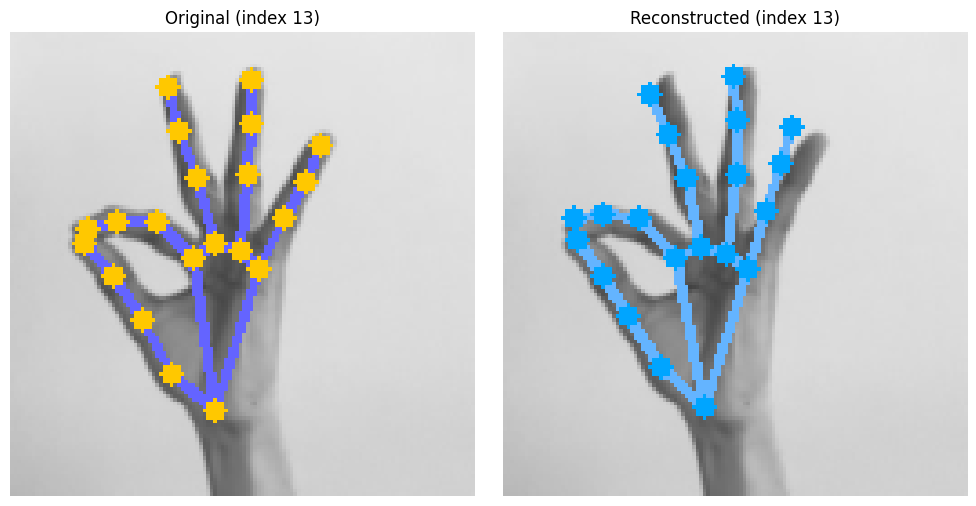

In [23]:
idx = 13  # change this to view another sample from the batch
model_kp.eval()
with torch.no_grad():
    data_img, _ = next(iter(val_loader_img))
    data_kp, _ = next(iter(val_loader_kp))
    data_kp = data_kp.to(device)
    recon_kp = model_kp.reconstruct(data_kp)
image_sample = data_img[idx]  # same sample as data_kp[idx] (loaders share order)
# 1) Raw image with keypoints overlaid (original left, reconstructed right)
plot_hand_keypoints_on_image(
    image_sample,
    data_kp[idx].cpu().numpy(),
    recon_kp[idx].cpu().numpy(),
    title_left=f"Original (index {idx})",
    title_right=f"Reconstructed (index {idx})",
)

#### Latent space visualization (keypoint AE)

Encode the validation set with the keypoint AE and scatter **continuous encoder latents** (t-SNE if dim > 2), **colored by ground-truth letter labels** from the CSV (supervised coloring — not unsupervised clustering). If `USE_VQ=True`, the next cell after KMeans colors the same latents by **VQ code index**.

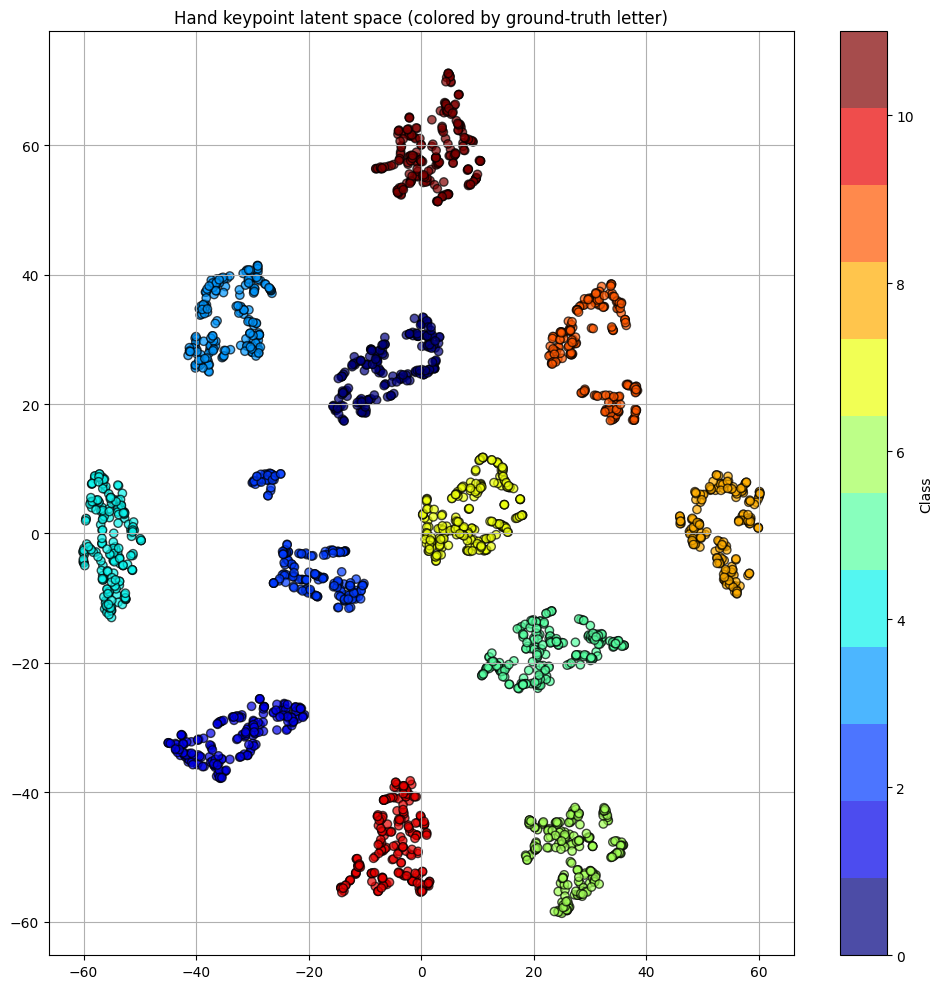

In [25]:
model_kp.eval()
latents_kp, labels_kp = [], []
with torch.no_grad():
    for data, lbl in val_loader_kp:
        data = data.to(device)
        z = model_kp.encode(data)
        latents_kp.append(z.cpu().numpy())
        labels_kp.append(lbl.numpy())
latents_kp = np.concatenate(latents_kp, axis=0)
labels_kp = np.concatenate(labels_kp, axis=0)
scatter_latent(
    latents_kp,
    labels_kp,
    title="Hand keypoint latent space (colored by ground-truth letter)",
)

#### KMeans clustering in latent space

Visualize keypoint AE latents colored by KMeans cluster assignments for unsupervised structure.

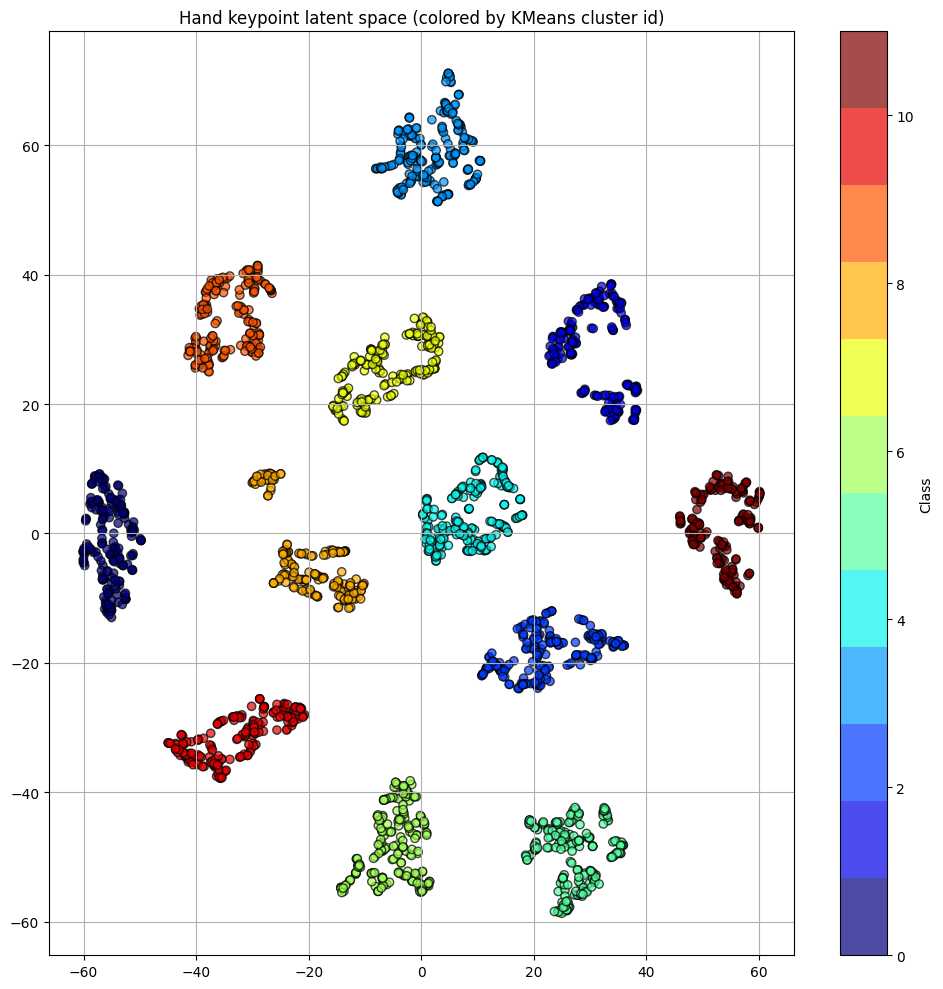

In [26]:
# Same latents as previous cell; color by KMeans cluster id (unsupervised)
from sklearn.cluster import KMeans

n_clusters = len(np.unique(labels_kp))  # optional: set to another int (e.g. 8) if you prefer
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(latents_kp)
scatter_latent(
    latents_kp,
    cluster_ids,
    title="Hand keypoint latent space (colored by KMeans cluster id)",
)

#### Train Keypoint VQ-VAE
Train a VQ-VAE model on hand keypoint data to learn a compact discrete latent space.l

In [27]:
device = get_device()
# Set USE_VQ=True for VQ-VAE (vq_layer: nb_code=512, ema_reset, vq_mu=0.99, commit_weight=0.02)
USE_VQ = True
model_kp = LinearAE(
    latent_dim=16,
    input_dim=63,
    hidden_dim=1024,
    use_vq=USE_VQ,
    nb_code=12,
    quantizer="ema_reset",
    vq_mu=0.99,
    commit_weight=0.02,
)
trainer_kp = AETrainer(model_kp, train_loader_kp, val_loader_kp, device=device)
trainer_kp.run(n_epochs=10)

  0%|          | 0/606 [00:00<?, ?it/s]

====> Epoch: 1 Train loss: 0.0087
====> Epoch: 1 Val loss: 0.0053


====> Epoch: 2 Train loss: 0.0054
====> Epoch: 2 Val loss: 0.0050


====> Epoch: 3 Train loss: 0.0056
====> Epoch: 3 Val loss: 0.0052


====> Epoch: 4 Train loss: 0.0056
====> Epoch: 4 Val loss: 0.0054


...

====> Epoch: 6 Train loss: 0.0052
====> Epoch: 6 Val loss: 0.0055


====> Epoch: 7 Train loss: 0.0053
====> Epoch: 7 Val loss: 0.0059


====> Epoch: 8 Train loss: 0.0055
====> Epoch: 8 Val loss: 0.0047


====> Epoch: 9 Train loss: 0.0050
====> Epoch: 9 Val loss: 0.0056


====> Epoch: 10 Train loss: 0.0051
====> Epoch: 10 Val loss: 0.0048


#### Visualize Latent Space with VQ-VAE Codebook Indices
After training the VQ-VAE, this cell colors each latent vector by its assigned codebook index, 
providing insight into how the learned discrete latent space clusters the hand keypoint data.

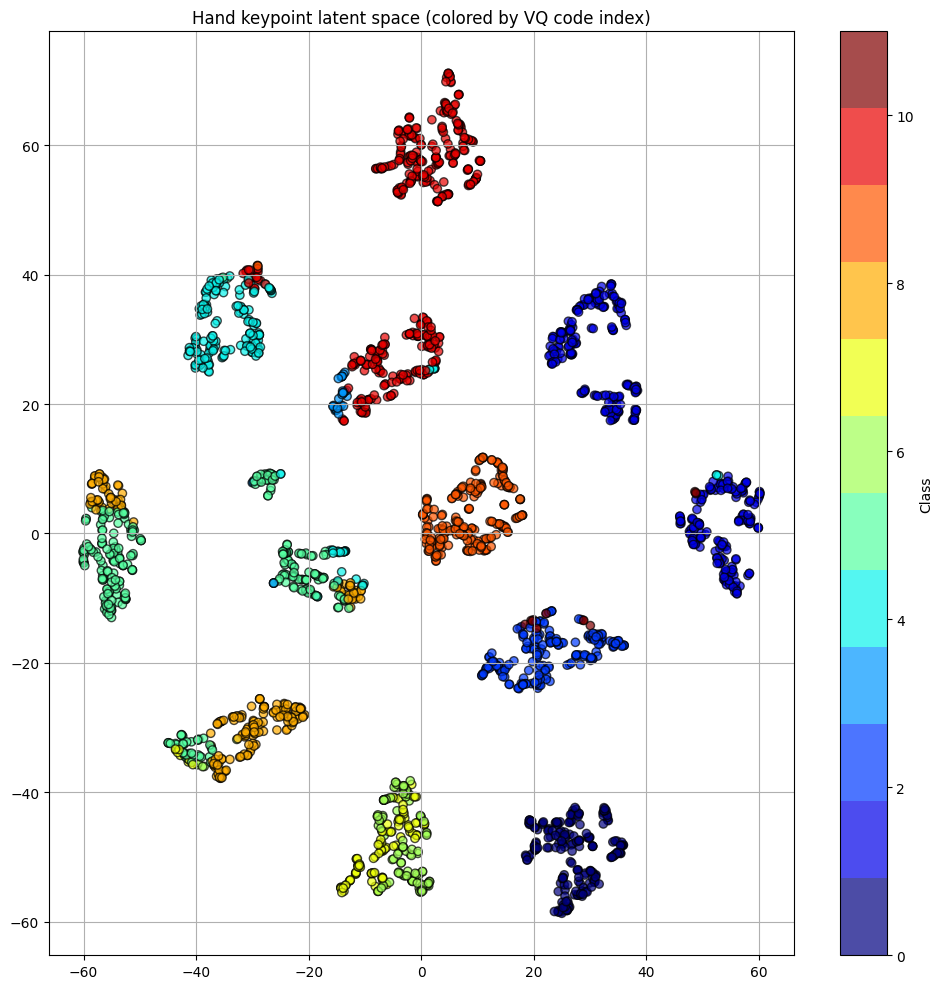

In [28]:
# If USE_VQ: same latent vectors as above, colored by VQ codebook index (0 .. nb_code-1)
if getattr(model_kp, "use_vq", False):
    model_kp.eval()
    vq_codes = []
    with torch.no_grad():
        for data, _ in val_loader_kp:
            data = data.to(device)
            vq_codes.append(model_kp.quantize_indices(data).cpu().numpy())
    vq_codes = np.concatenate(vq_codes, axis=0)
    scatter_latent(
        latents_kp,
        vq_codes,
        title="Hand keypoint latent space (colored by VQ code index)",
    )
else:
    print("Set USE_VQ=True in the training cell and retrain to plot VQ code-colored latents.")